This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - picking task batteries of 3 to 28 tasks.

In [59]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import construct as ct
import itertools
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


In [60]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
base_dir = 'Y:/data'

# start with some U_true, in this simulation 5 parcels

In [61]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [62]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [63]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

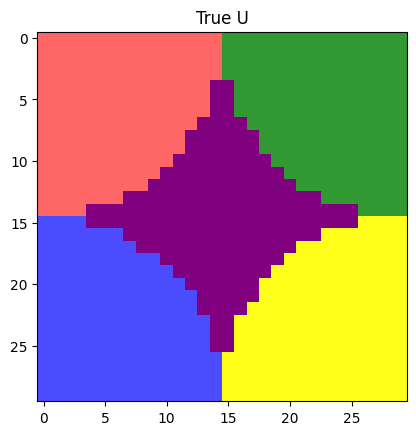

In [64]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5,device=device, dtype=pt.float64)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5.cpu().numpy(), title = 'True U')

# run analysis

In [65]:
battery_sizes = [3,4,5,6,7,8,12,16,20]
metrics = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc']
num_task_lib = 100
n_parcels = 5
base_noise = 0.2


n_iter = 20
n_batteries = 10000

In [ ]:
iteration_df = pd.DataFrame()
for i in range(n_iter):
    print(f'Iteration{i}')
    results_df = sim.sim_parcellation(num_task_lib = num_task_lib,
                     n_parcels = n_parcels,
                     U_true = U_true_5,
                     battery_sizes = battery_sizes,
                     n_batteries = n_batteries,
                     base_noise = base_noise,
                     seed = None)
    results_df['iteration'] = i
    iteration_df = pd.concat([iteration_df,results_df],axis=0)

Iteration0
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Processing battery size: 20
Iteration1
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Processing battery size: 20
Iteration2
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6


In [ ]:
# Save results
# results_df.to_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_parcellation.tsv', index=False)
# #load results
# results_df = pd.read_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/simulation_parcellation.tsv')


# plot

In [ ]:
summary_df = iteration_df.groupby(['n_task', 'metric'])['accuracy'].agg(
    mean_accuracy='mean',
    sem_accuracy=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()


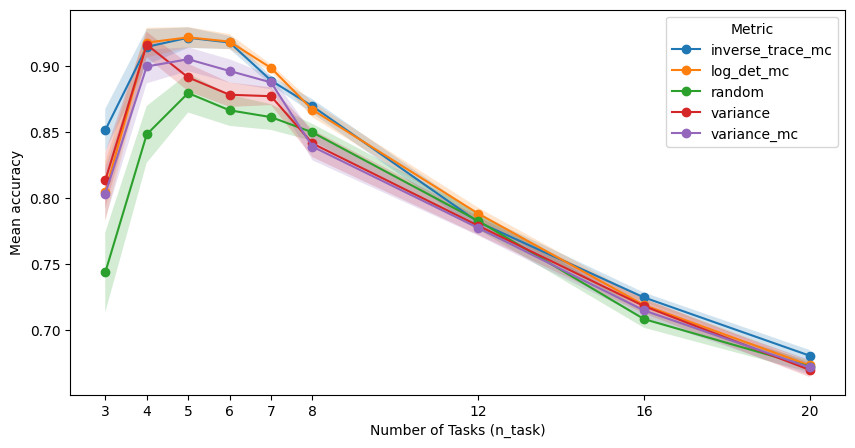

In [ ]:
plt.figure(figsize=(10, 5))
for metric in summary_df['metric'].unique():
    subset = summary_df[summary_df['metric'] == metric]
    plt.plot(subset['n_task'], subset['mean_accuracy'], marker='o', label=metric)
    plt.fill_between(subset['n_task'],
                     subset['mean_accuracy'] - subset['sem_accuracy'],
                     subset['mean_accuracy'] + subset['sem_accuracy'],
                     alpha=0.2) 

plt.xlabel("Number of Tasks (n_task)")
plt.xticks(battery_sizes)
plt.ylabel("Mean accuracy")
plt.legend(title="Metric")
plt.show()


# stats

In [ ]:
def compute_corrected_pvals(results_df, battery_sizes, metrics, correction="bonferroni"):
    """Computes Bonferroni-corrected pairwise t-test p-values for each n_task."""
    pvals_list = []

    for n_t in battery_sizes:
        df_sub = results_df[results_df['n_task'] == n_t]
        pairs = list(itertools.combinations(metrics, 2))

        # ttest and collect pvals
        raw_pvals = [ttest_ind(df_sub[df_sub['metric'] == m1]['accuracy'], 
                               df_sub[df_sub['metric'] == m2]['accuracy'], 
                               equal_var=False)[1]
                     for m1, m2 in pairs]

        # multiple comparisons correction?
        _, pvals_bonf, _, _ = multipletests(raw_pvals, alpha=0.05, method=correction)
        for (idx, (m1, m2)) in enumerate(pairs):
            pvals_list.append({
                "n_task": n_t,
                "metric_1": m1,
                "metric_2": m2,
                "raw_p": raw_pvals[idx],
                "corrected_p": pvals_bonf[idx]
            })

    return pd.DataFrame(pvals_list)

In [ ]:
pval_df = compute_corrected_pvals(iteration_df, battery_sizes, metrics)

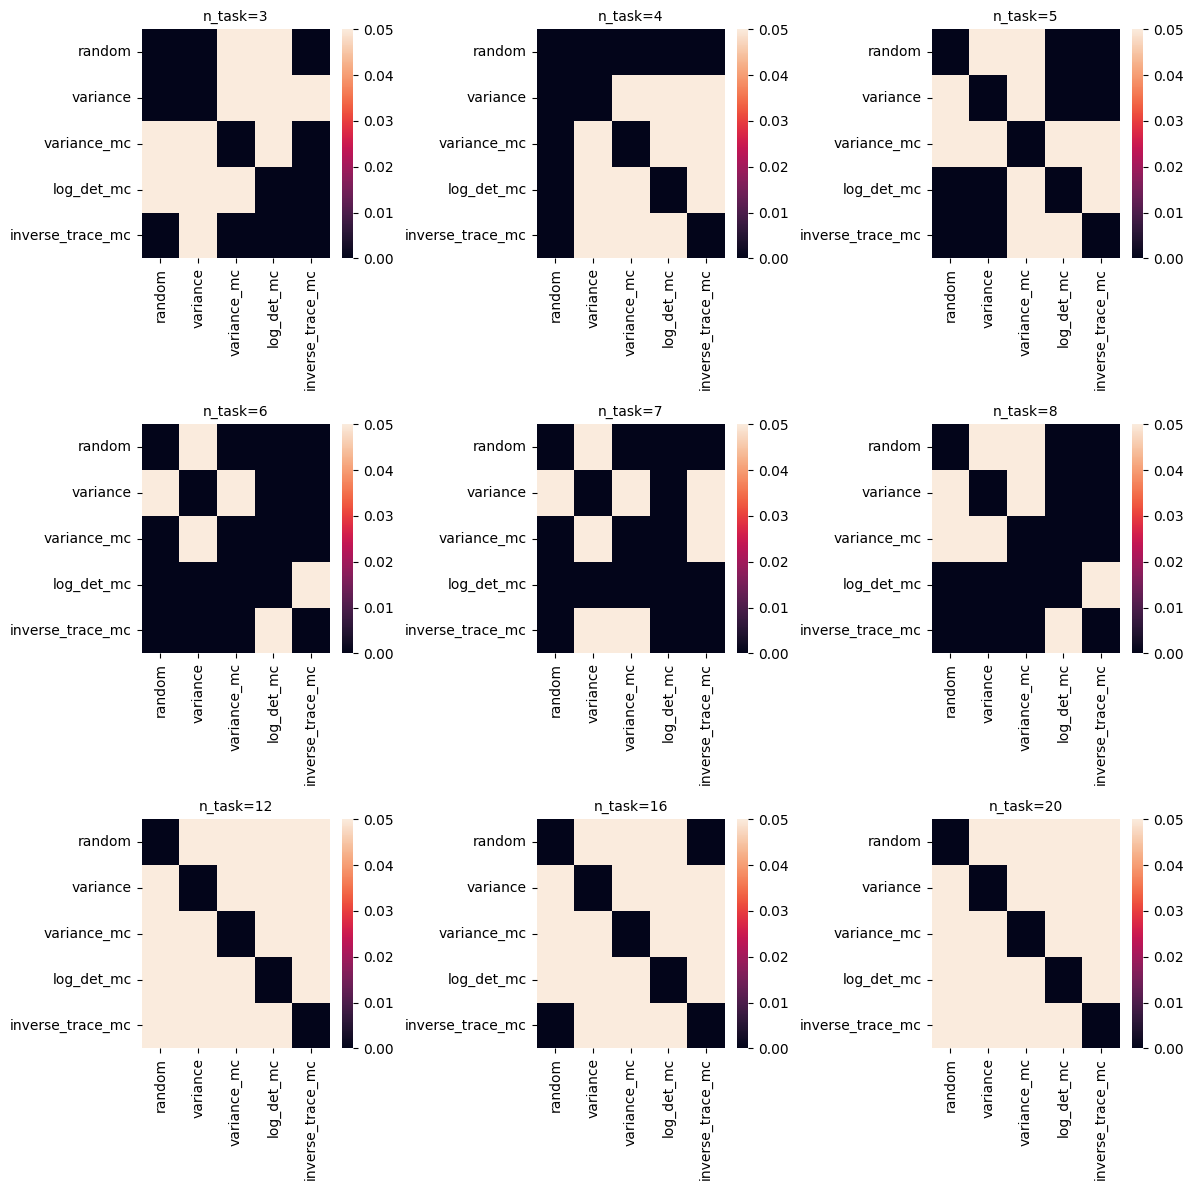

In [ ]:
def plot_pval_heatmap(pval_table, battery_sizes, metrics):
    """Plots a heatmap of corrected p-values for each n_task."""
    num_n_tasks = len(battery_sizes)
    num_cols = 3 
    num_rows = (num_n_tasks + num_cols - 1) // num_cols 

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 4*num_rows))
    axes = np.ravel(axes)  

    for i, n_t in enumerate(battery_sizes):
        ax = axes[i]
        df_sub = pval_table[pval_table["n_task"] == n_t]

        # initlize
        pval_matrix = np.full((len(metrics), len(metrics)), 0)

        # fill
        for _, row_data in df_sub.iterrows():
            i, j = metrics.index(row_data["metric_1"]), metrics.index(row_data["metric_2"])
            pval_matrix[i, j] = pval_matrix[j, i] = row_data["corrected_p"]

        #plot
        sns.heatmap(pval_matrix, xticklabels=metrics, 
                    yticklabels=metrics, cbar=True, vmin=0, vmax=0.05, ax=ax)

        ax.set_title(f"n_task={n_t}", fontsize=10)

    plt.tight_layout()
    plt.show()

plot_pval_heatmap(pval_df, battery_sizes, metrics)
